In [10]:
import wandb
import pandas as pd

api = wandb.Api()
entity = "wulff"
project = "vla_understanding"

runids = [
    "9tqi41re", # Attribution-Patching-little-goshawk
    "tjbkk2cg", # lime starling
    "wbgwhyho",  # observant whippet
    "ruz5w78d",  # warping hoatzin
    "q96u8b6j"  # ochre cicada
]

labels = [
    "Directional",
    "Semantic Scaling (Noun)",
    "Semantic Scaling (Verb)",
    "Synonym (Noun)",
    "Synonym (Verb)"
]

mean_stds_clean = []
mean_stds_corrupted = []
mean_diffs = []
for runid in runids:
    run = api.run(f"{entity}/{project}/{runid}")

    history = run.scan_history(keys=["corrupted_loss", "clean_loss"])
    df = pd.DataFrame(history)

    diffs = df["corrupted_loss"] - df["clean_loss"]
    mean_diffs.append((diffs.mean(), diffs.sem()))
    mean, std = df[["corrupted_loss", "clean_loss"]].mean(), df[["corrupted_loss", "clean_loss"]].sem()
    print(f"Run {runid} ({run.name}):")
    print(f"  Mean corrupted_loss: {mean['corrupted_loss']:.4f} ± {std['corrupted_loss']:.4f}")
    print(f"  Mean clean_loss: {mean['clean_loss']:.4f} ± {std['clean_loss']:.4f}")
    mean_stds_clean.append((mean['clean_loss'], std['clean_loss']))
    mean_stds_corrupted.append((mean['corrupted_loss'], std['corrupted_loss']))
    print(df)  # columns: _step, corrupted_loss, clean_loss (and possibly _runtime, _timestamp)


Run 9tqi41re (Attribution-Patching-little-goshawk):
  Mean corrupted_loss: 0.6881 ± 0.0053
  Mean clean_loss: 0.6855 ± 0.0053
       corrupted_loss  clean_loss
0            0.541863    0.296273
1            0.461871    0.288927
2            0.244518    0.234002
3            0.351398    0.432085
4            0.865039    0.377650
...               ...         ...
17022        0.836557    0.312830
17023        0.321290    0.405947
17024        0.624829    0.320547
17025        0.236764    0.224230
17026        0.614512    0.547637

[17027 rows x 2 columns]
Run tjbkk2cg (Attribution-Patching-lime-starling):
  Mean corrupted_loss: 0.7699 ± 0.0028
  Mean clean_loss: 0.7601 ± 0.0028
       corrupted_loss  clean_loss
0            0.422163    0.387291
1            0.792699    0.463717
2            0.999807    0.798870
3            0.755416    0.536584
4            0.392279    0.626359
...               ...         ...
25364        0.521470    1.797944
25365        1.224560    0.494355
25366    

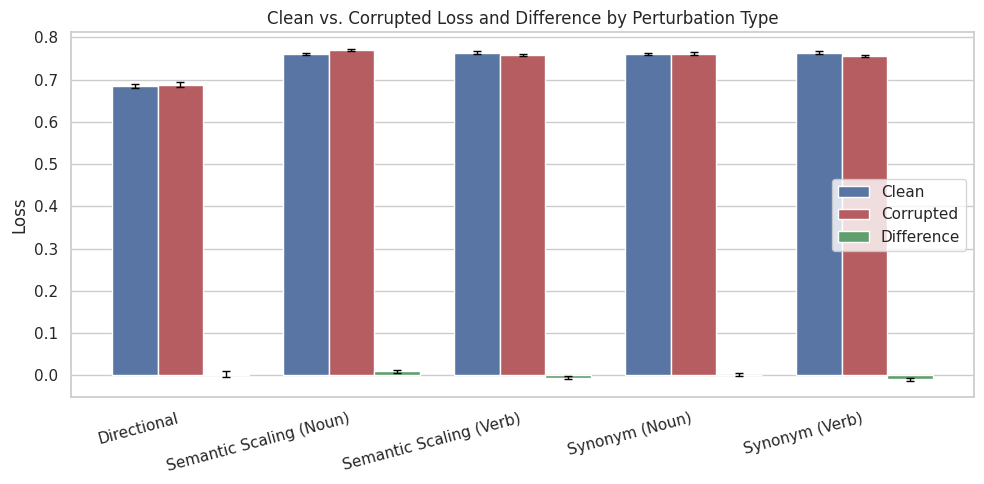

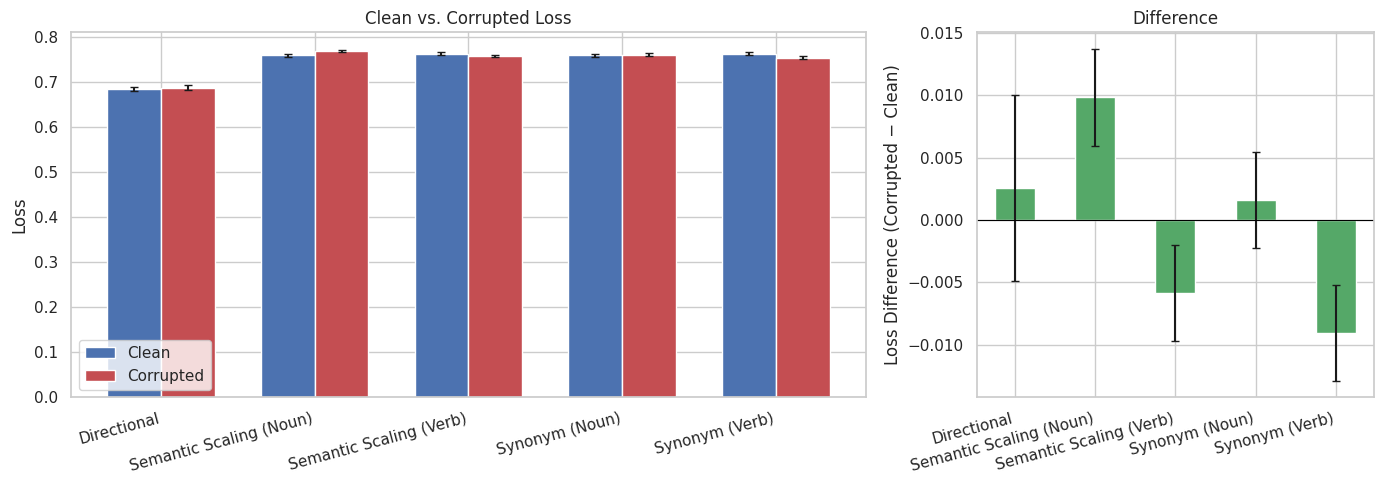

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Build long-form DataFrame
rows = []
for i, label in enumerate(labels):
    clean_mean, clean_std = mean_stds_clean[i]
    corr_mean, corr_std = mean_stds_corrupted[i]
    diff_mean, diff_std = mean_diffs[i]

    rows.append({"label": label, "condition": "Clean", "mean": clean_mean, "std": clean_std})
    rows.append({"label": label, "condition": "Corrupted", "mean": corr_mean, "std": corr_std})
    rows.append({"label": label, "condition": "Difference", "mean": diff_mean, "std": diff_std})

df = pd.DataFrame(rows)

# Plot
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 5))

palette = {"Clean": "#4C72B0", "Corrupted": "#C44E52", "Difference": "#55A868"}

bar = sns.barplot(
    data=df,
    x="label",
    y="mean",
    hue="condition",
    palette=palette,
    errorbar=None,   # we'll add std error bars manually
    ax=ax,
)

# Manually add error bars matching each bar's position
# seaborn groups bars by hue order within each x category
n_conditions = df["condition"].nunique()
bar_width = None
for i, p in enumerate(ax.patches):
    # match patch to corresponding row via x position + height
    x_center = p.get_x() + p.get_width() / 2
    height = p.get_height()
    # find matching row (small float tolerance)
    match = df[np.isclose(df["mean"], height, atol=1e-8)]
    if not match.empty:
        std = match["std"].values[0]
        ax.errorbar(x_center, height, yerr=std, fmt="none", c="black", capsize=3, linewidth=1)

ax.set_xlabel("")
ax.set_ylabel("Loss")
ax.set_title("Clean vs. Corrupted Loss and Difference by Perturbation Type")
ax.legend(title="")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [2, 1]})

# Left: Clean vs Corrupted grouped bars
x = np.arange(len(labels))
width = 0.35
clean_means, clean_stds = zip(*mean_stds_clean)
corr_means, corr_stds = zip(*mean_stds_corrupted)

ax1.bar(x - width/2, clean_means, width, yerr=clean_stds, capsize=3, label="Clean", color="#4C72B0")
ax1.bar(x + width/2, corr_means, width, yerr=corr_stds, capsize=3, label="Corrupted", color="#C44E52")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=15, ha="right")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.set_title("Clean vs. Corrupted Loss")

# Right: Difference alone, its own scale
diff_means, diff_stds = zip(*mean_diffs)
ax2.bar(x, diff_means, width=0.5, yerr=diff_stds, capsize=3, color="#55A868")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=15, ha="right")
ax2.set_ylabel("Loss Difference (Corrupted − Clean)")
ax2.set_title("Difference")

plt.tight_layout()
plt.show()

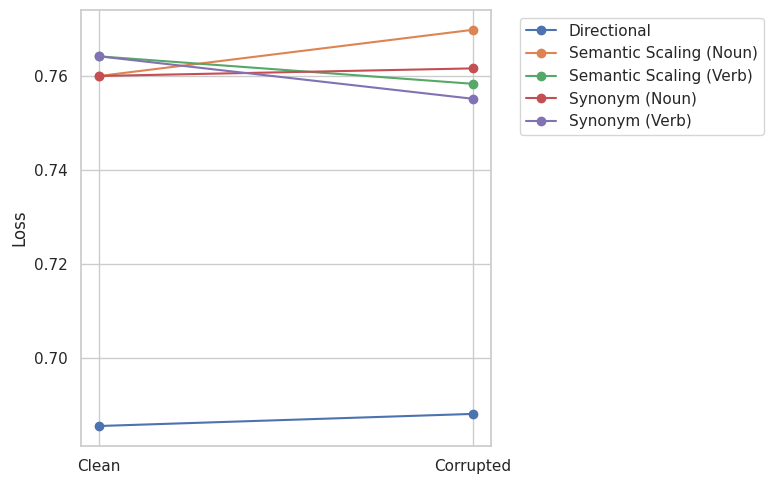

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
for i, label in enumerate(labels):
    c_mean, c_std = mean_stds_clean[i]
    x_mean, x_std = mean_stds_corrupted[i]
    ax.plot([0, 1], [c_mean, x_mean], marker="o", label=label)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Clean", "Corrupted"])
ax.set_ylabel("Loss")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()